## About Dataset

Lending Club

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


Grade | Risk Level | Typical Interest Rate
---|---:|---:
A | Lowest risk | ~6–8%
B | Low risk | ~9–12%
C | Moderate risk | ~13–16%
D | Medium-high risk | ~17–20%
E | High risk | ~21–24%
F | Very high risk | ~25–28%
G | Highest risk | ~29%+

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
pd.options.display.max_rows = None

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

100%|██████████| 339M/339M [00:02<00:00, 136MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1


In [7]:
import os
print(os.listdir(path))

['LCDataDictionary.xlsx', 'loan.csv']


In [8]:
df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 75000)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,75000.0,15861.884333,10162.640008,1000.00,8000.0000,13500.000,21000.0000,4.000000e+04
funded_amnt,75000.0,15861.884333,10162.640008,1000.00,8000.0000,13500.000,21000.0000,4.000000e+04
funded_amnt_inv,75000.0,15858.938000,10164.992407,725.00,8000.0000,13500.000,21000.0000,4.000000e+04
int_rate,75000.0,13.046117,4.956675,6.00,8.8100,11.800,16.1400,3.094000e+01
installment,75000.0,460.123855,285.298178,30.64,250.1100,380.540,620.8275,1.618240e+03
annual_inc,75000.0,83208.190837,109313.472978,0.00,48000.0000,69000.000,100000.0000,9.757200e+06
url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check missing values

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
id,75000
member_id,75000
hardship_start_date,75000
deferral_term,75000
hardship_status,75000
hardship_loan_status,75000
orig_projected_additional_accrued_interest,75000
hardship_payoff_balance_amount,75000
hardship_last_payment_amount,75000
settlement_status,75000


In [11]:
drop_missing_columns = list(df.columns[df.isnull().sum() > 50000])
drop_missing_columns

['id',
 'member_id',
 'url',
 'desc',
 'mths_since_last_record',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',


In [12]:
len(drop_missing_columns)

42

In [13]:
df.drop(columns = drop_missing_columns, inplace=True)

In [14]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

#### Check variable variance

In [15]:
df[numerical].apply(lambda x: x.std()).sort_values()

,0
acc_now_delinq,0.000000
policy_code,0.000000
collection_recovery_fee,0.000000
recoveries,0.000000
num_tl_120dpd_2m,0.000000
tax_liens,0.000000
num_tl_30dpd,0.000000
chargeoff_within_12_mths,0.093909
collections_12_mths_ex_med,0.148694
pub_rec_bankruptcies,0.333121


In [16]:
df['chargeoff_within_12_mths'].value_counts()

,count
chargeoff_within_12_mths,
0,74528
1,439
2,25
3,5
4,2
7,1


In [17]:
df['policy_code'].value_counts()

,count
policy_code,
1,75000


In [18]:
df['num_tl_120dpd_2m'].value_counts()

,count
num_tl_120dpd_2m,
0.0,73192


In [19]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # tune this

numeric_cols = df.select_dtypes(include='number').columns

selector.fit(df[numeric_cols])

# See which columns are kept
kept = numeric_cols[selector.get_support()]
dropped = numeric_cols[~selector.get_support()]
print("Dropped:", dropped.tolist())

Dropped: ['recoveries', 'collection_recovery_fee', 'policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens']


In [20]:
len(dropped)

8

In [21]:
for col in categorical:
    print(col, df[col].nunique())
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

term 2
term
36 months    51386
60 months    23614
Name: count, dtype: int64

grade 7
grade
A    21566
B    21191
C    18432
D     9962
E     3749
F       74
G       26
Name: count, dtype: int64

sub_grade 34

emp_title 28063

emp_length 11

home_ownership 4
home_ownership
MORTGAGE    37092
RENT        29442
OWN          8268
ANY           198
Name: count, dtype: int64

verification_status 3
verification_status
Not Verified       35138
Source Verified    28576
Verified           11286
Name: count, dtype: int64

issue_d 2
issue_d
Dec-2018    40134
Nov-2018    34866
Name: count, dtype: int64

loan_status 6
loan_status
Current               72740
Fully Paid             1724
In Grace Period         260
Late (31-120 days)      182
Late (16-30 days)        82
Charged Off              12
Name: count, dtype: int64

pymnt_plan 1
pymnt_plan
n    75000
Name: count, dtype: int64

purpose 12

title 12

zip_code 871

addr_state 50

earliest_cr_line 629

initial_list_status 2
initial_list_status
w    

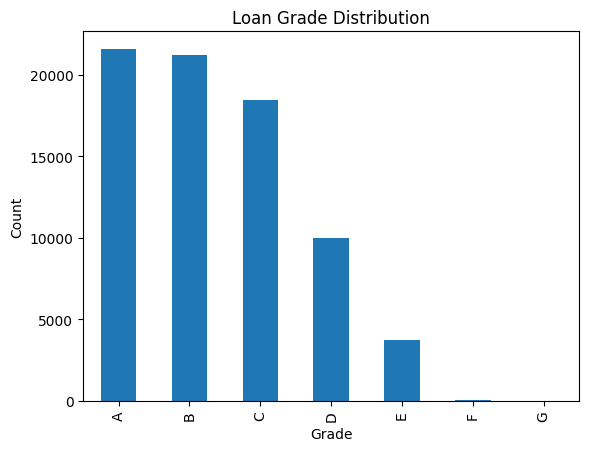

In [22]:
df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

### Bivariate charts

/tmp/ipykernel_5523/866535275.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


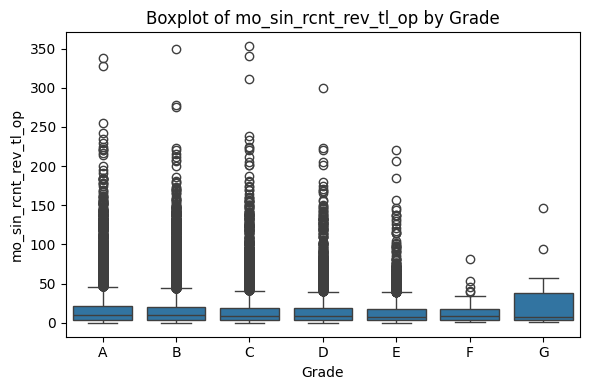

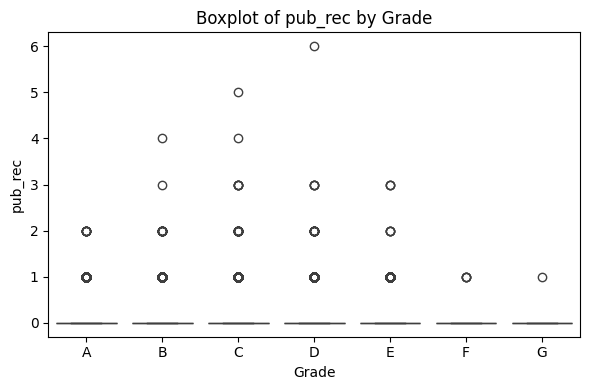

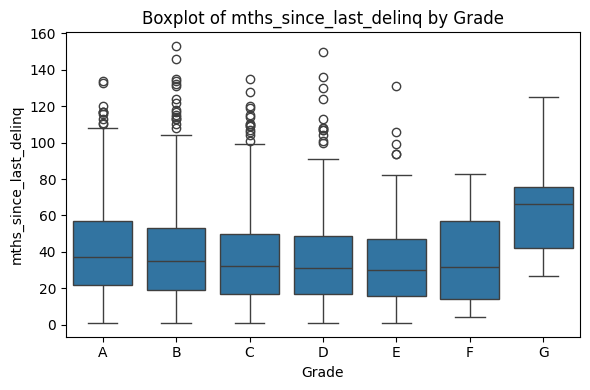

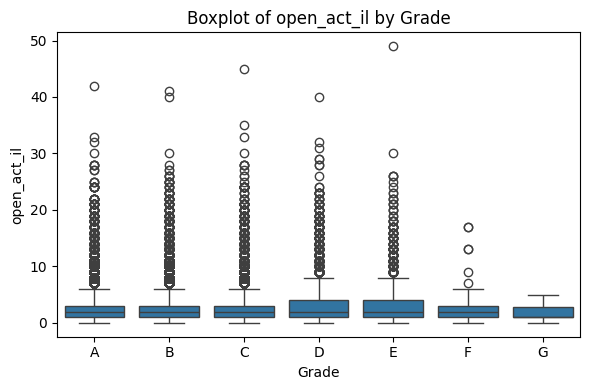

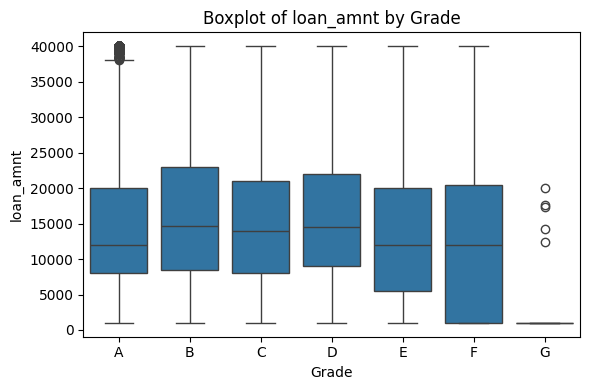

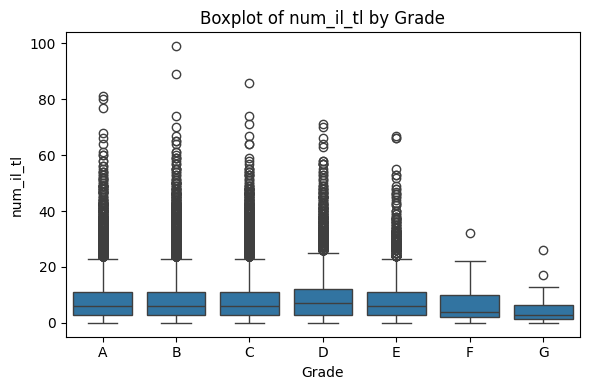

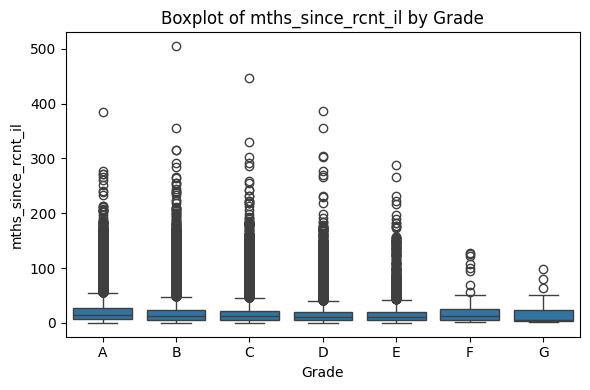

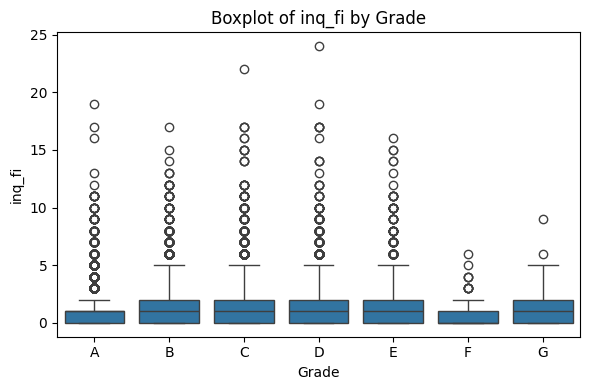

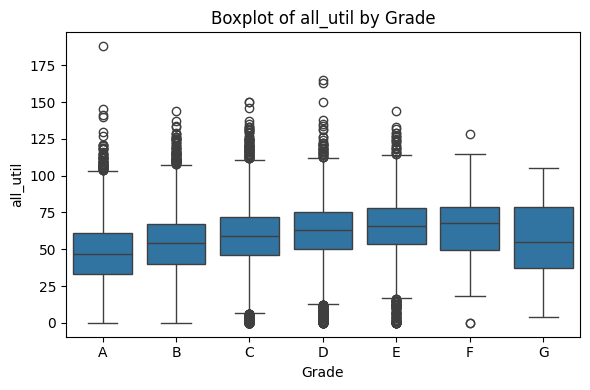

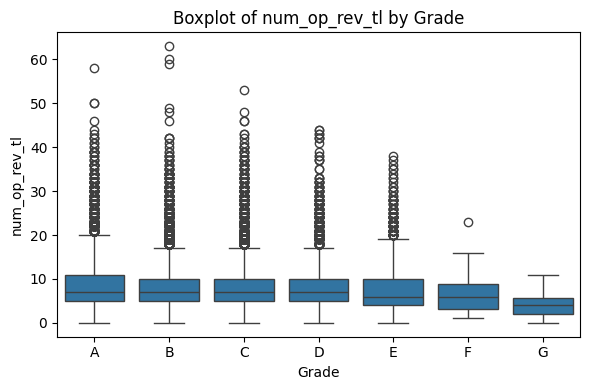

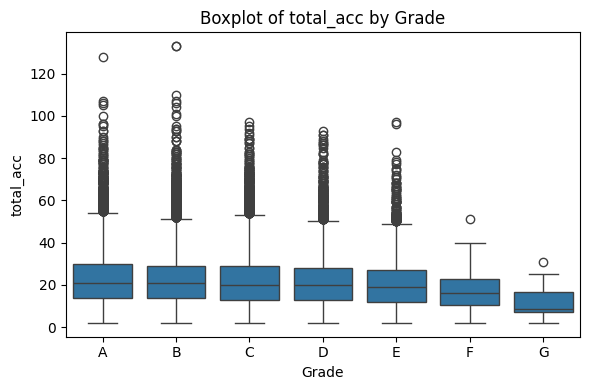

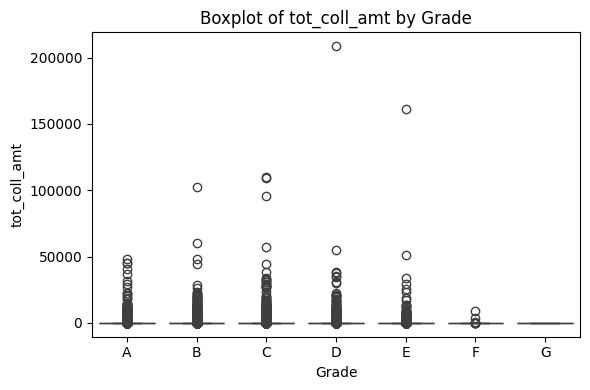

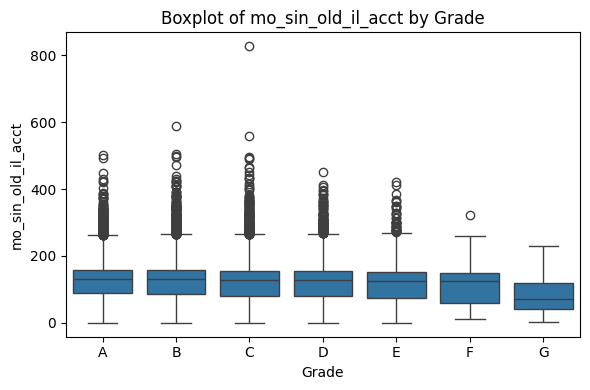

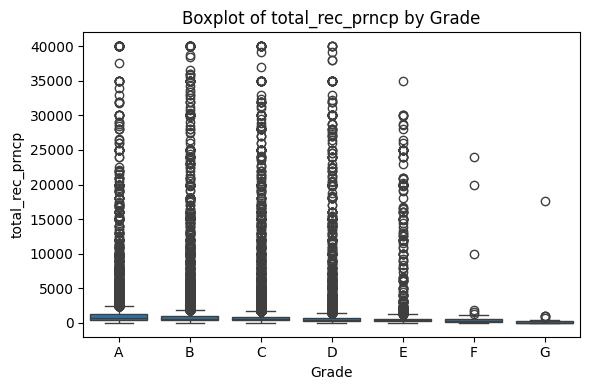

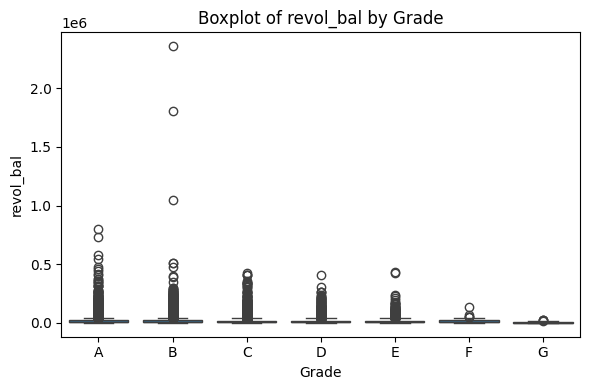

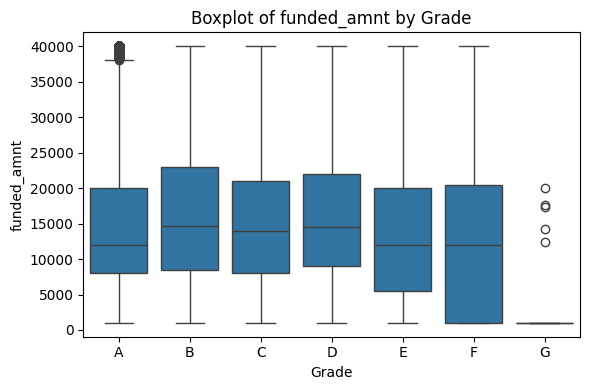

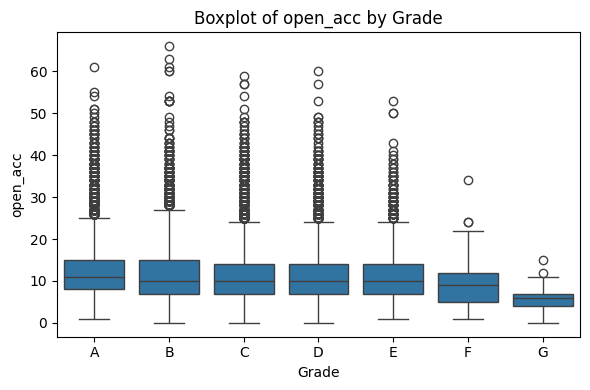

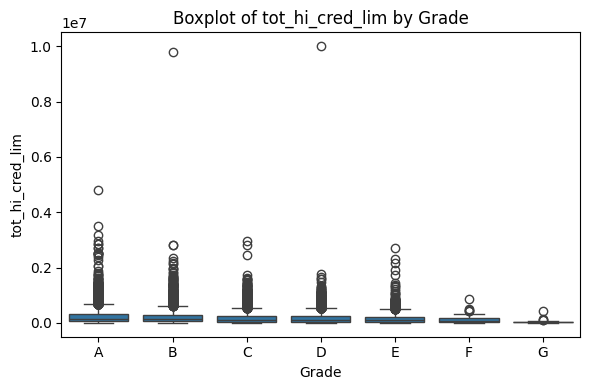

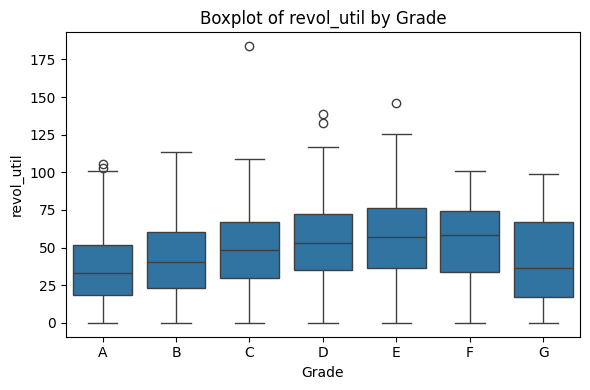

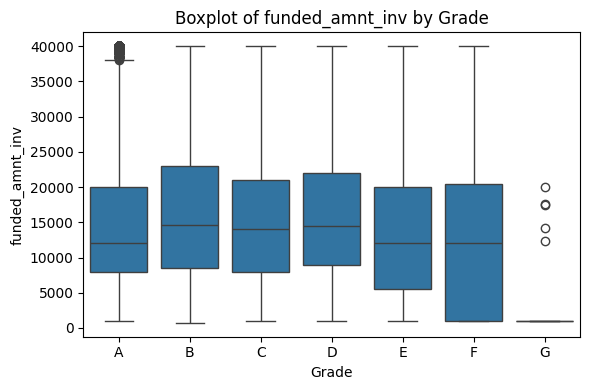

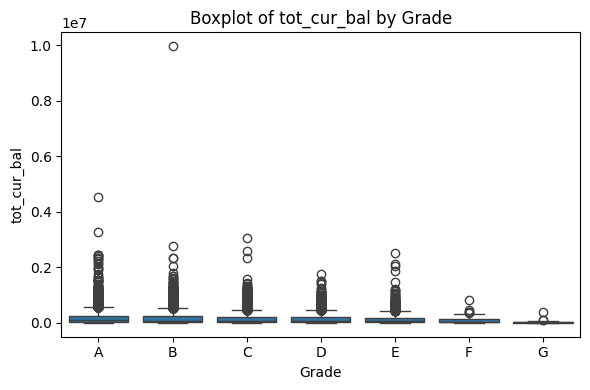

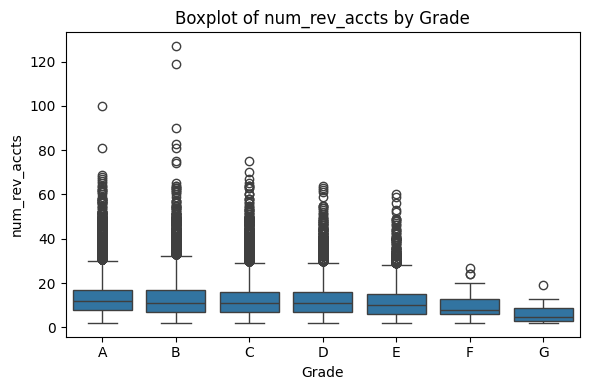

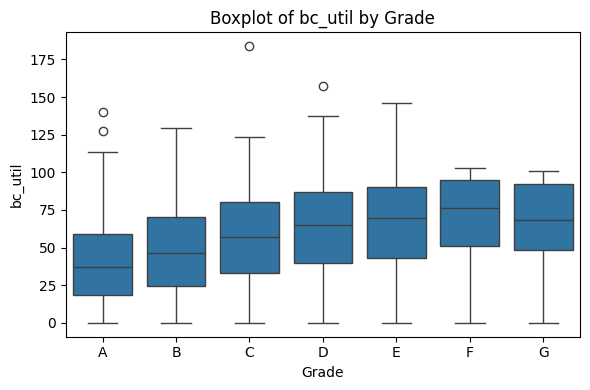

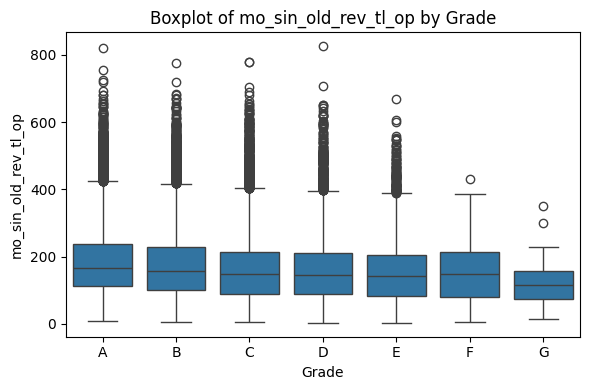

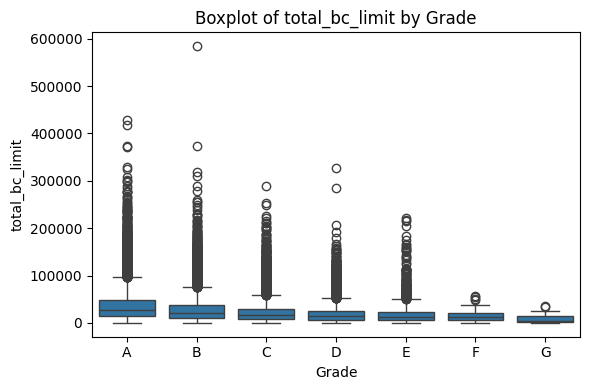

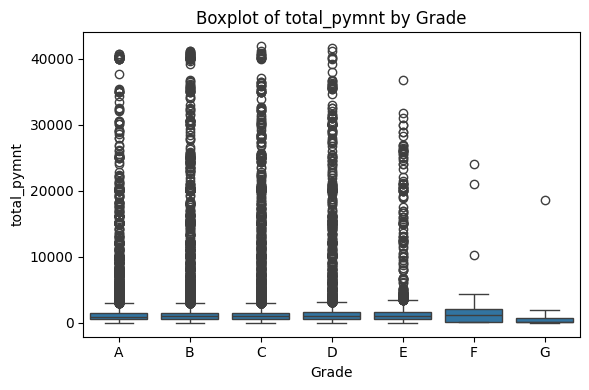

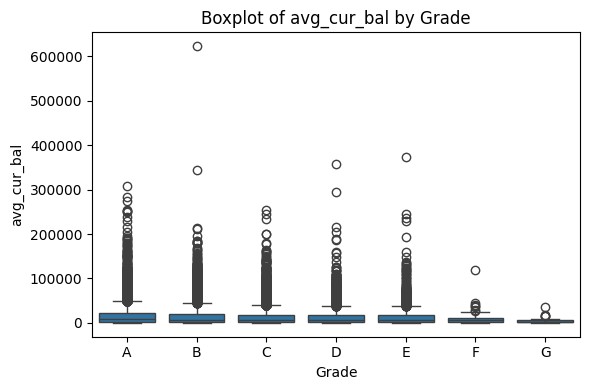

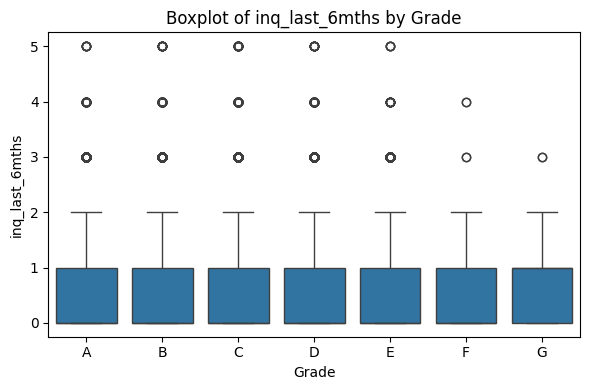

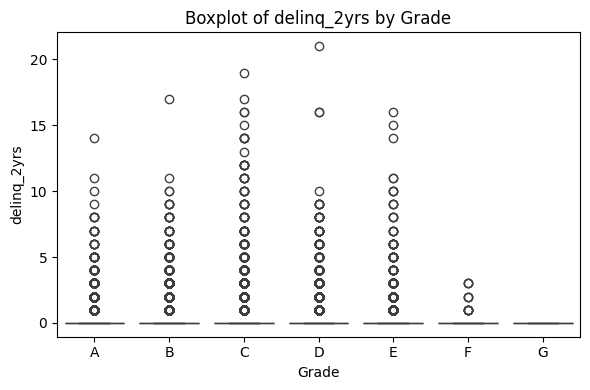

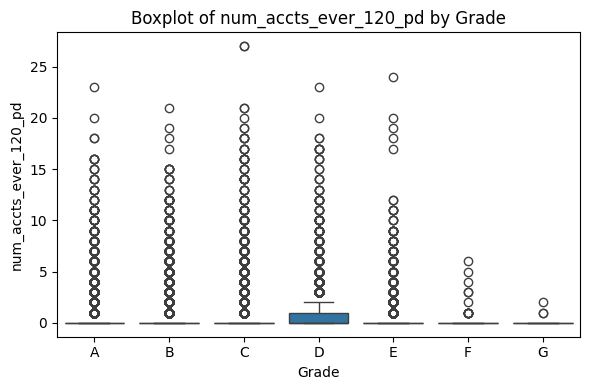

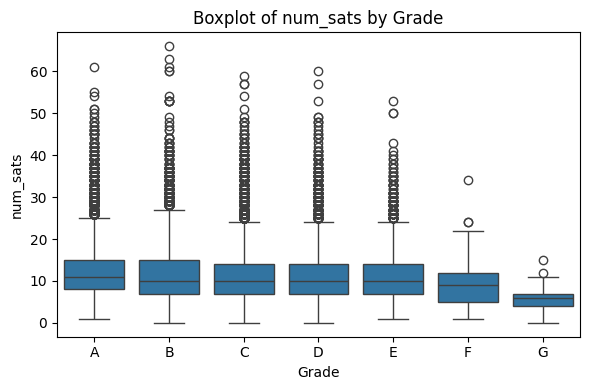

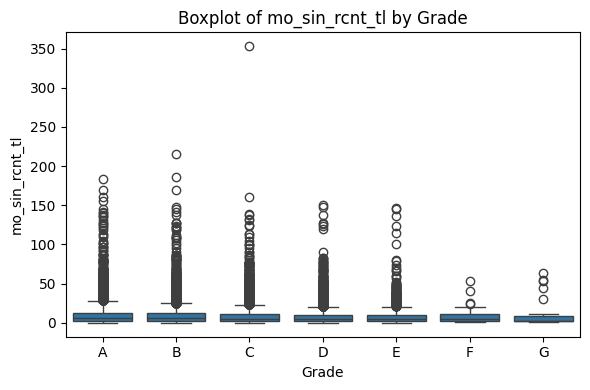

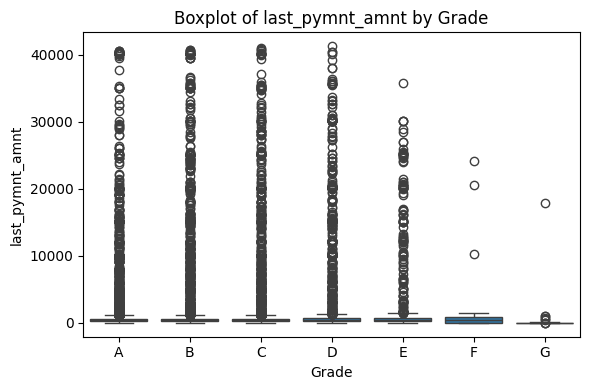

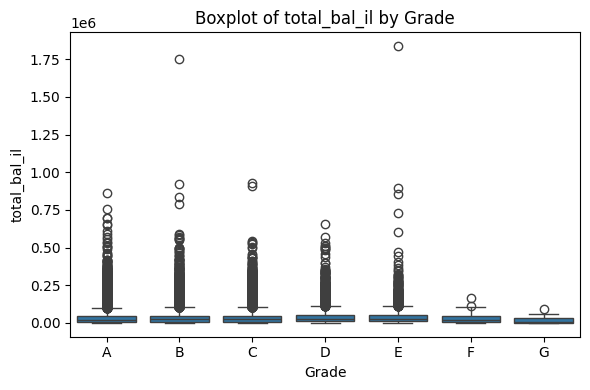

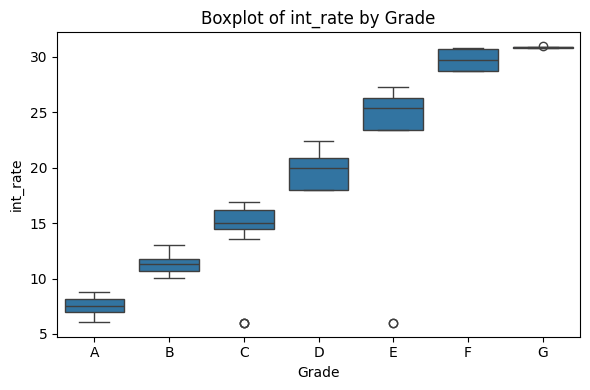

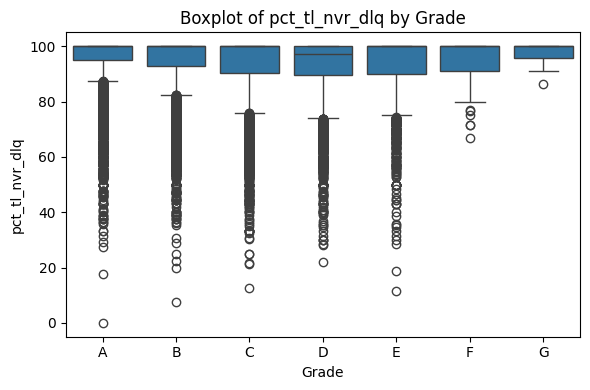

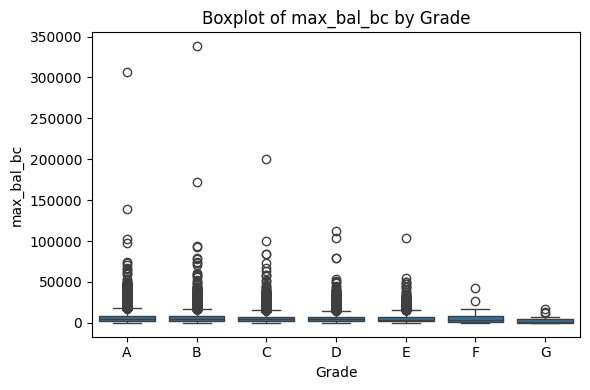

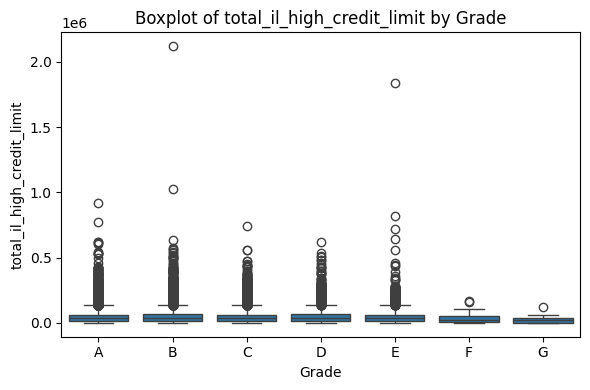

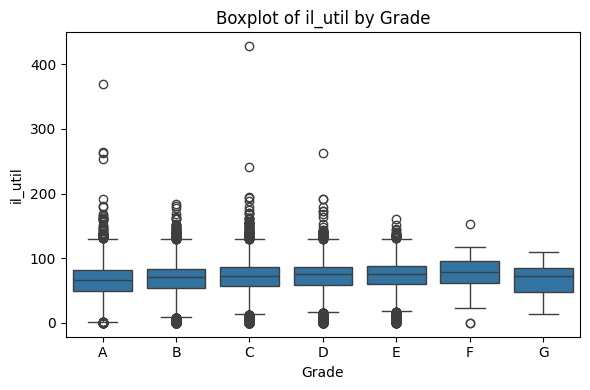

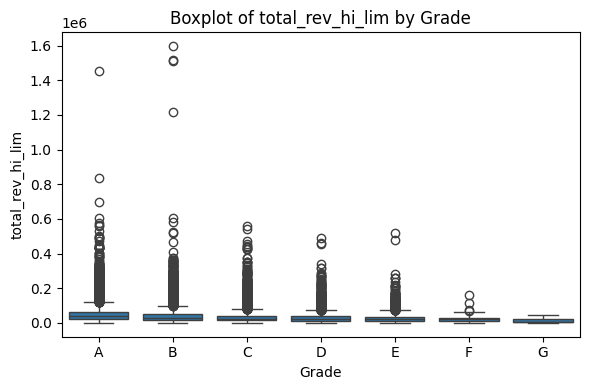

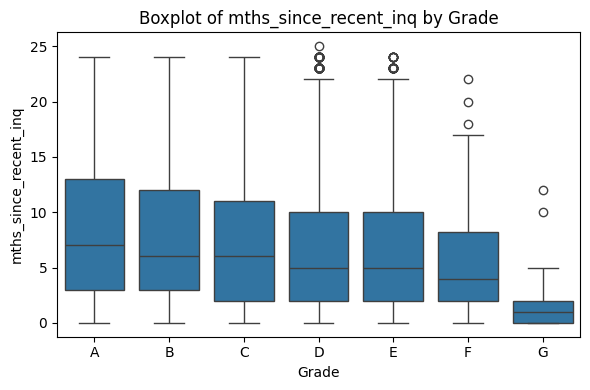

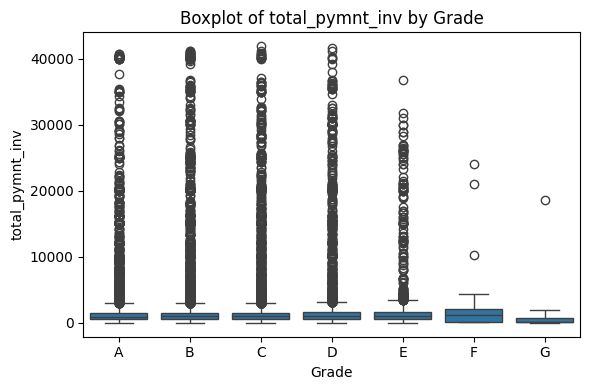

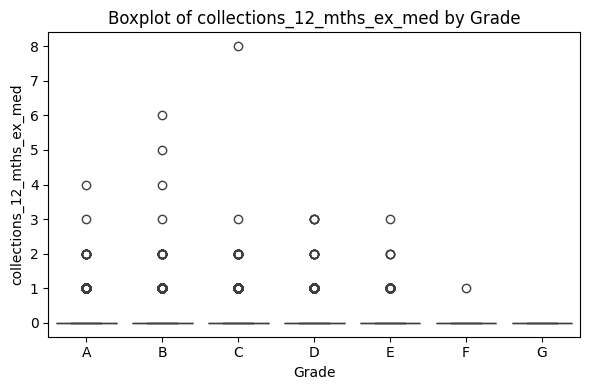

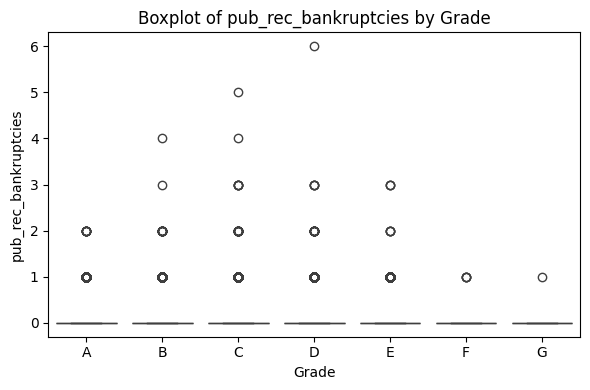

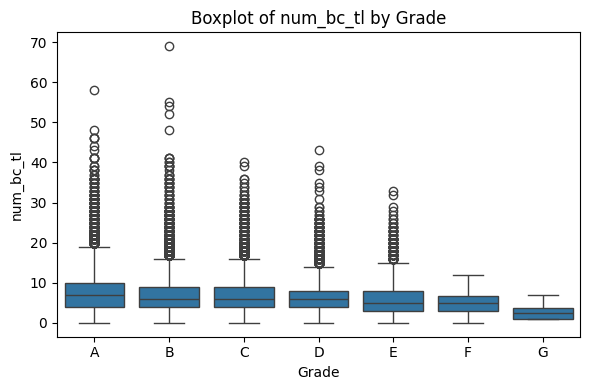

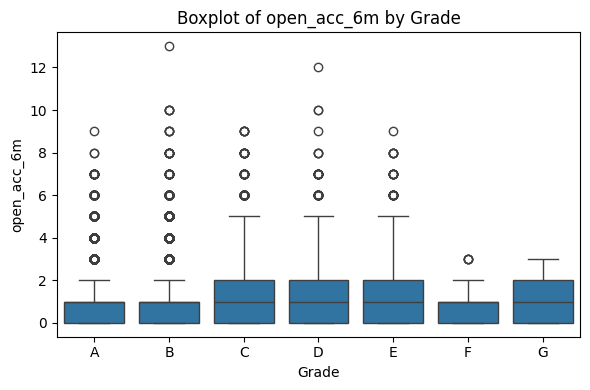

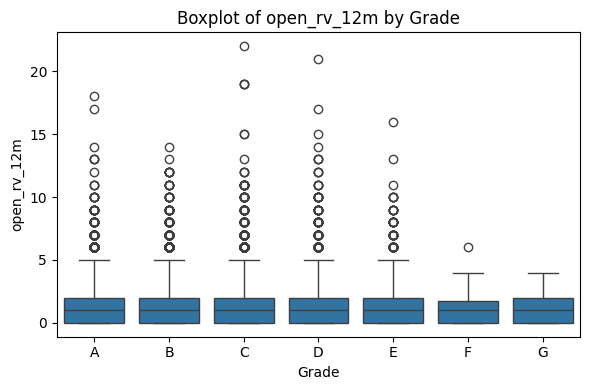

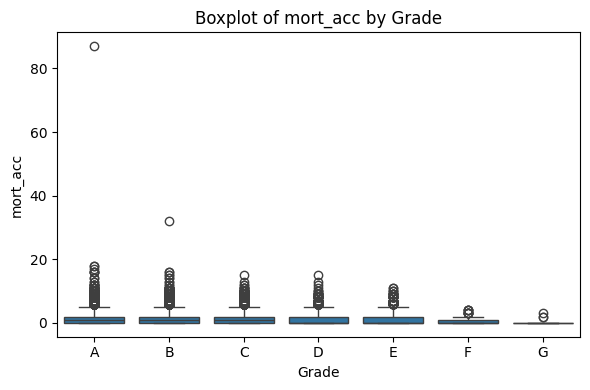

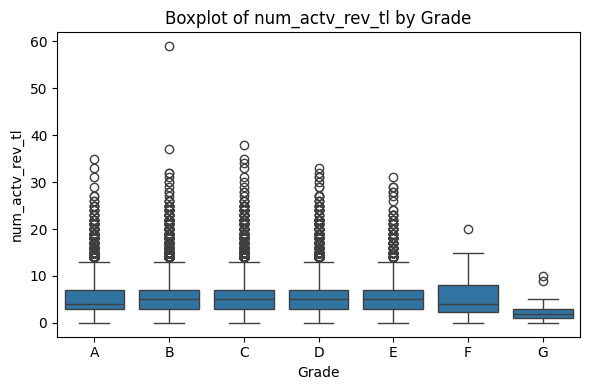

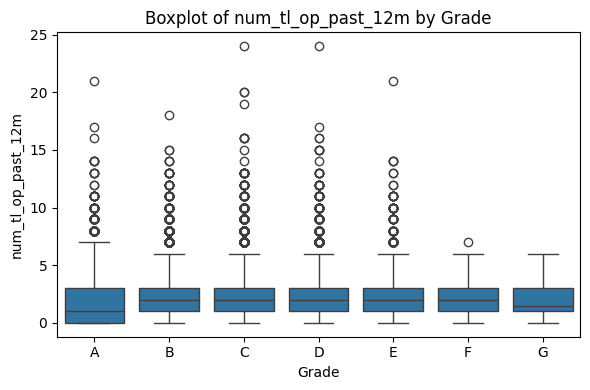

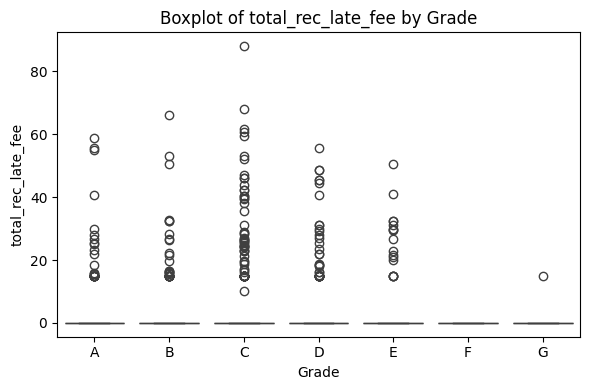

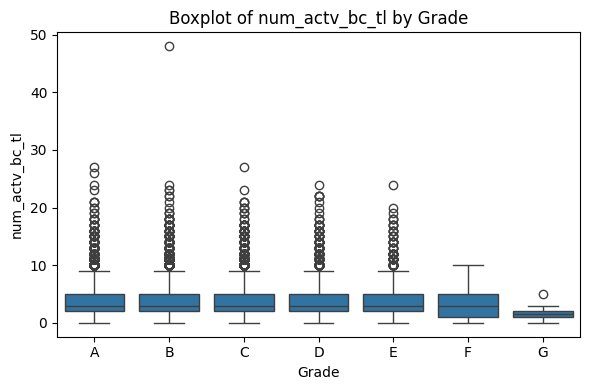

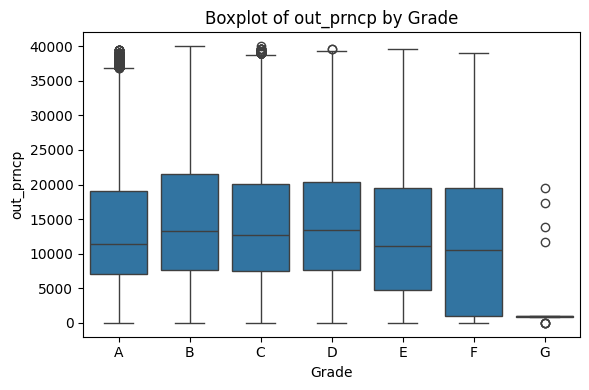

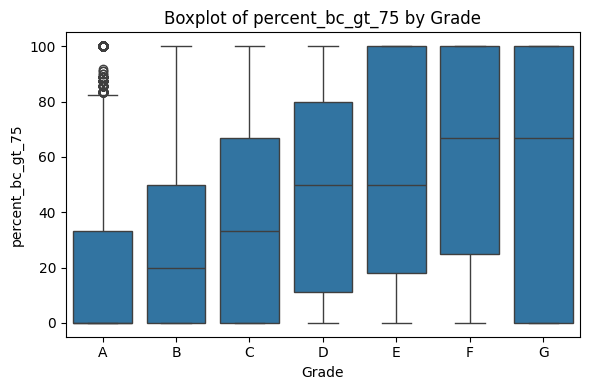

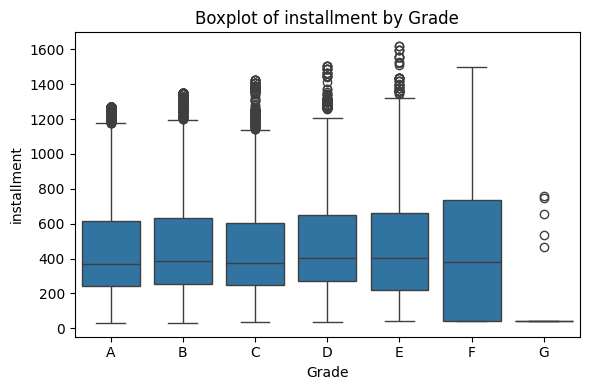

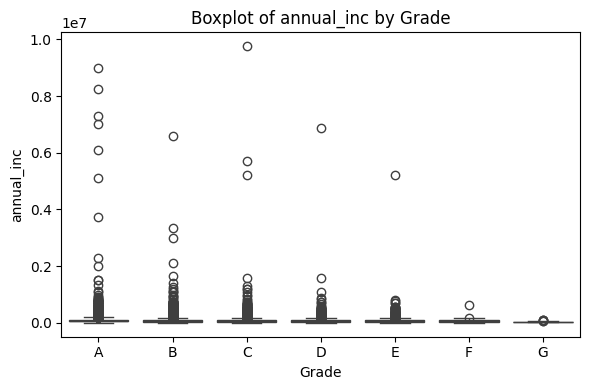

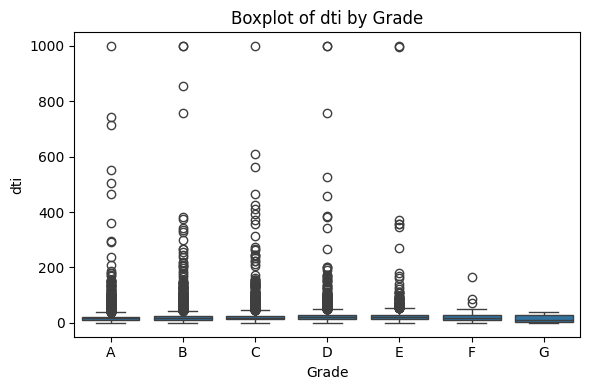

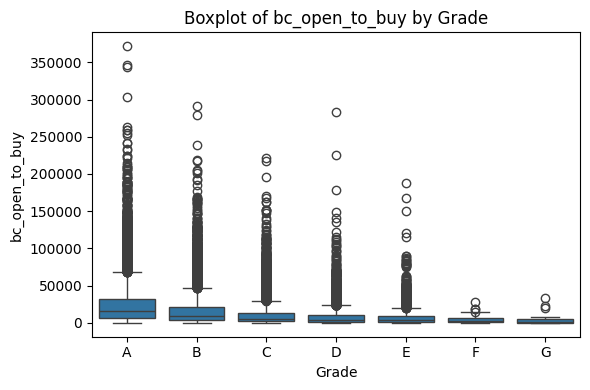

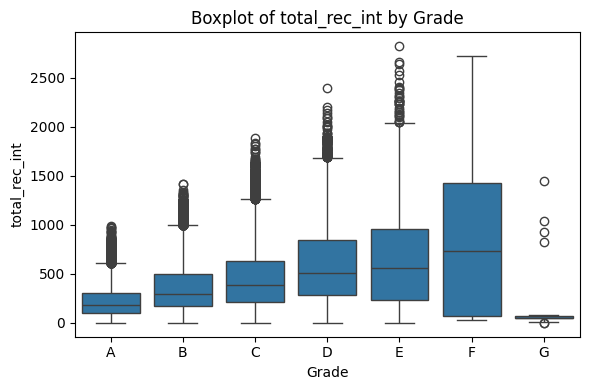

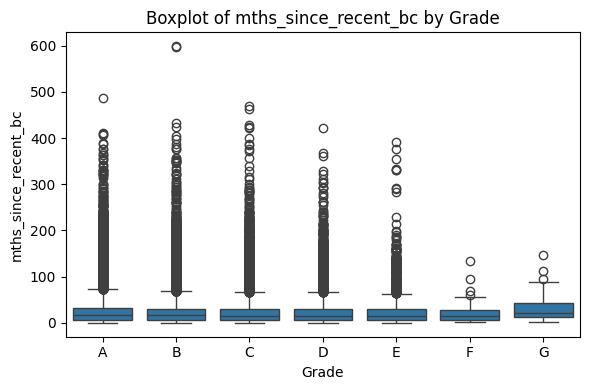

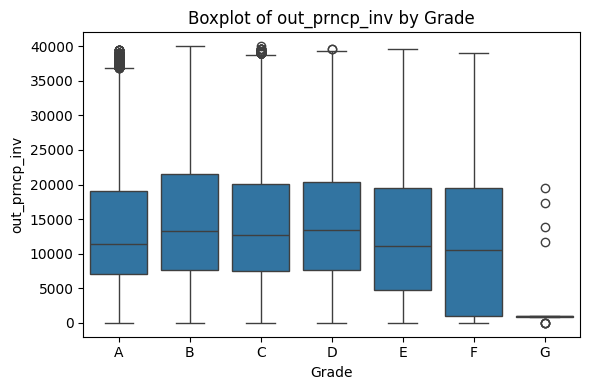

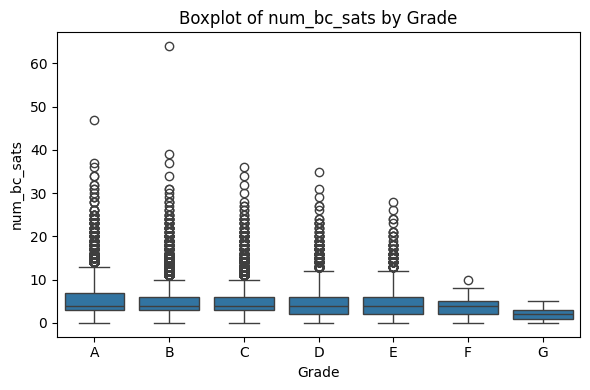

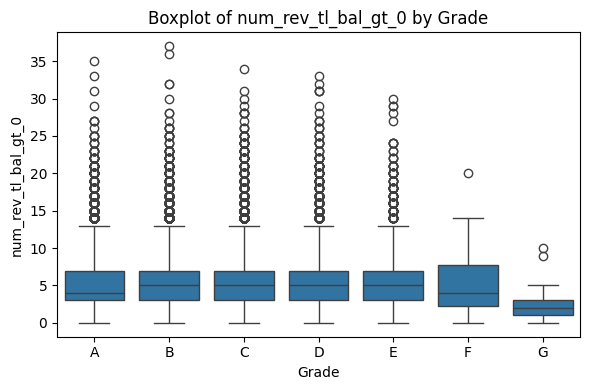

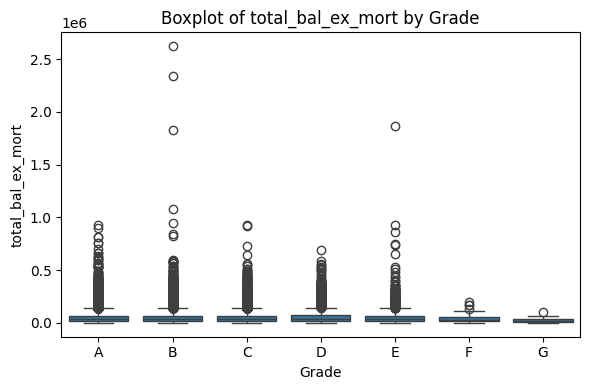

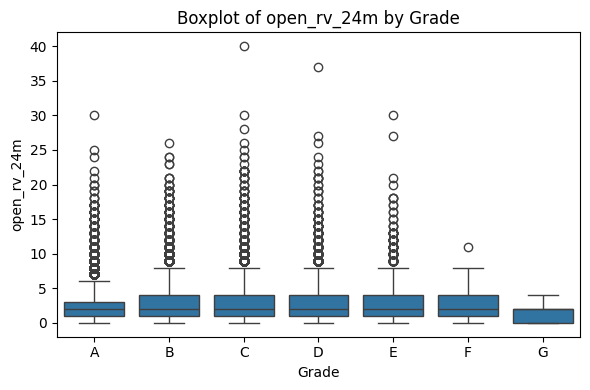

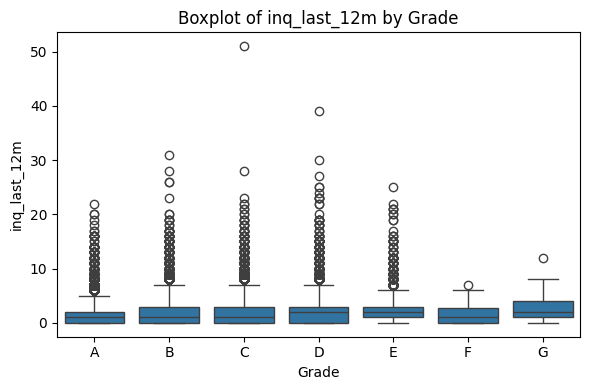

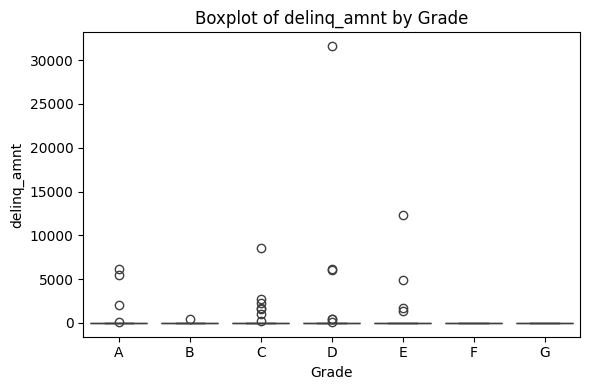

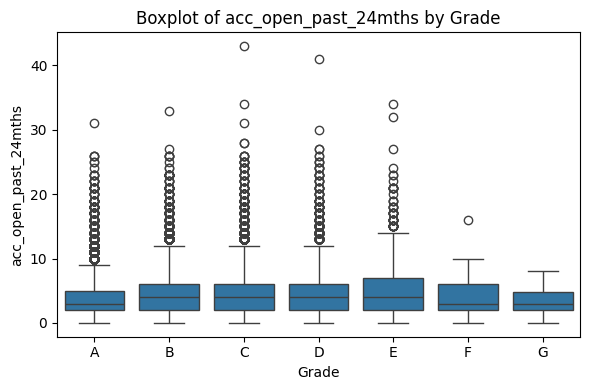

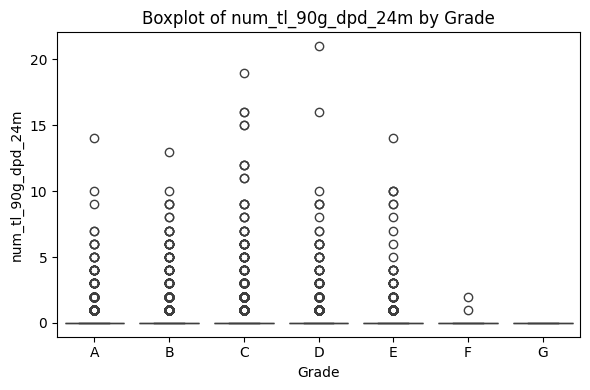

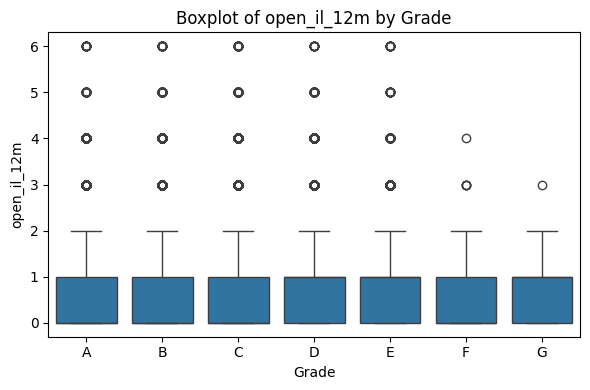

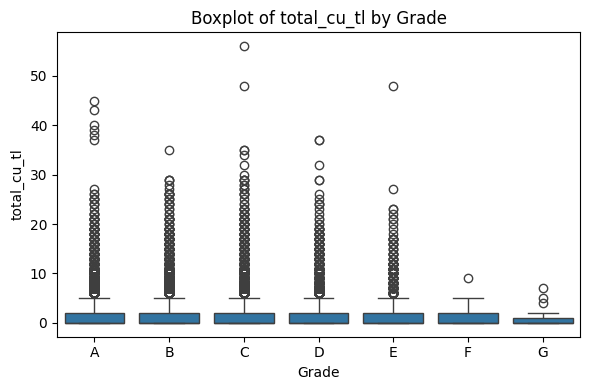

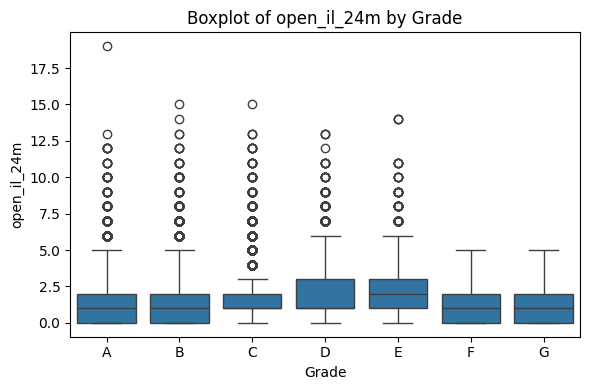

In [23]:
import seaborn as sns

num_features = set(kept) & set(numerical)

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='grade', y=col, order=sorted(df['grade'].unique()))
    plt.title(f'Boxplot of {col} by Grade')
    plt.xlabel('Grade')
    plt.ylabel(col)
    plt.tight_layout()

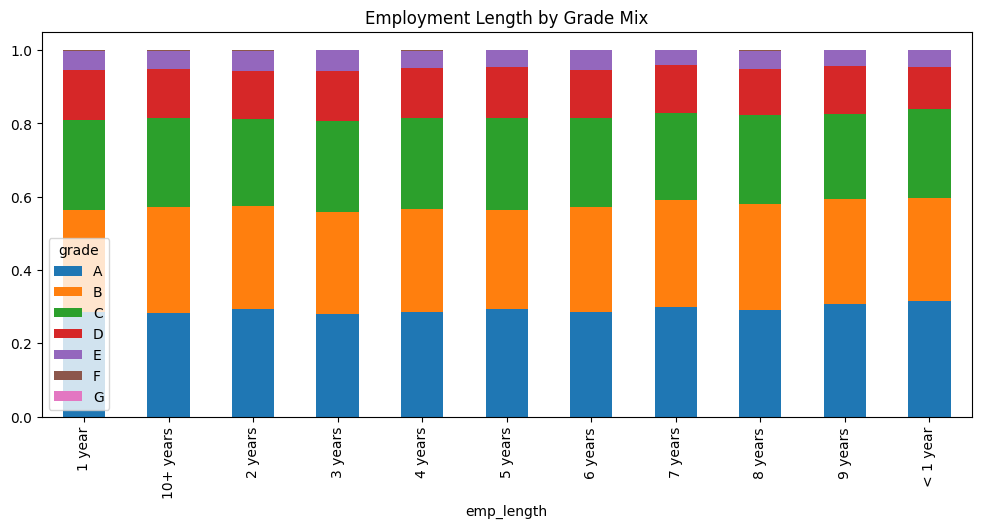

In [24]:
# Employment Length & Home Ownership
# Employment length
emp_grade = df.groupby(['emp_length', 'grade']).size().unstack(fill_value=0)
emp_grade_pct = emp_grade.div(emp_grade.sum(axis=1), axis=0)
emp_grade_pct.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Employment Length by Grade Mix')

order = ['< 1 year', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']


Text(0.5, 1.0, 'Home Ownership by Grade')

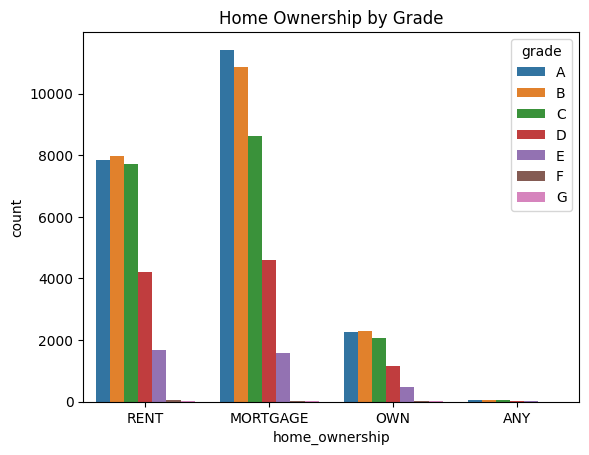

In [25]:
# Home ownership
sns.countplot(data=df, x='home_ownership', hue='grade', 
              hue_order=list('ABCDEFG'))
plt.title('Home Ownership by Grade')

### Correlation between categorical variables and target

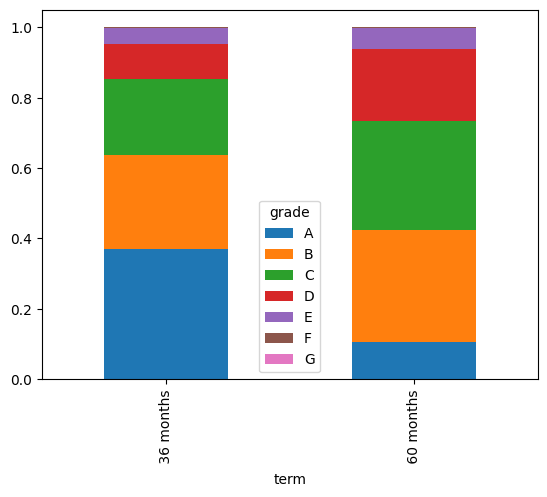

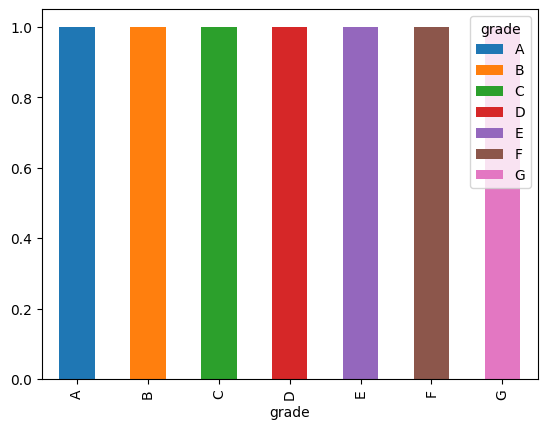

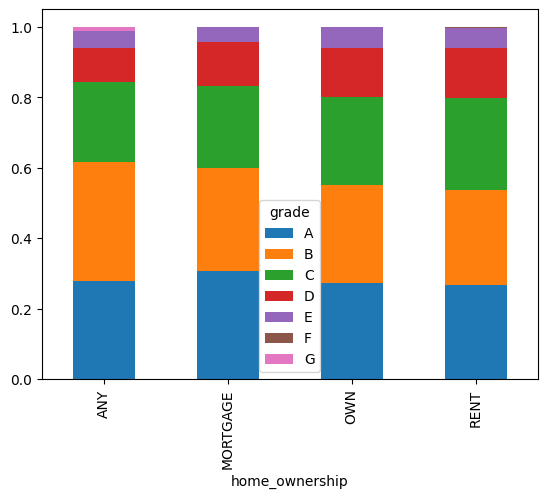

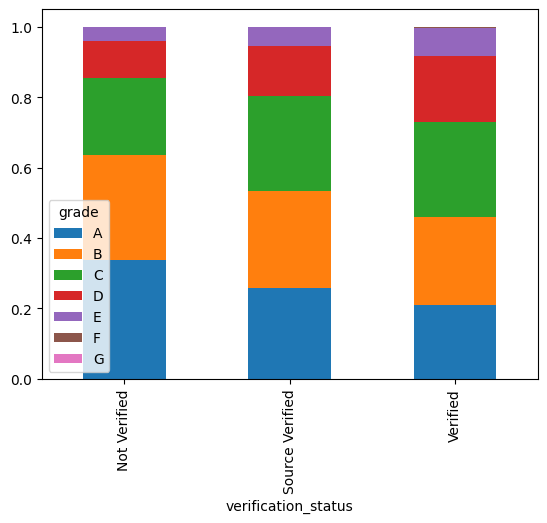

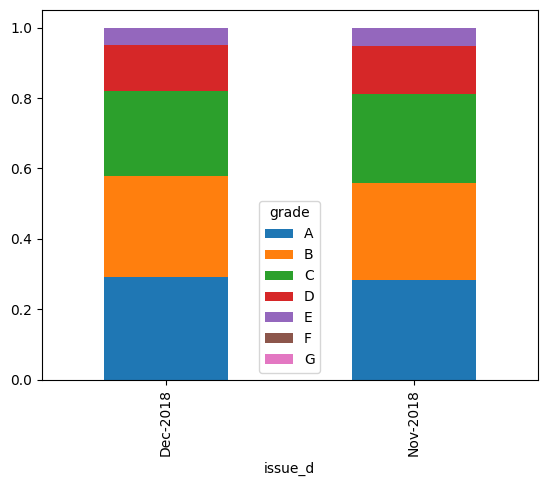

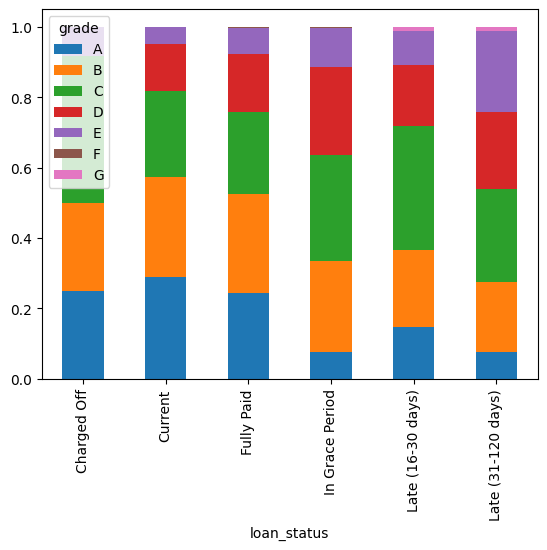

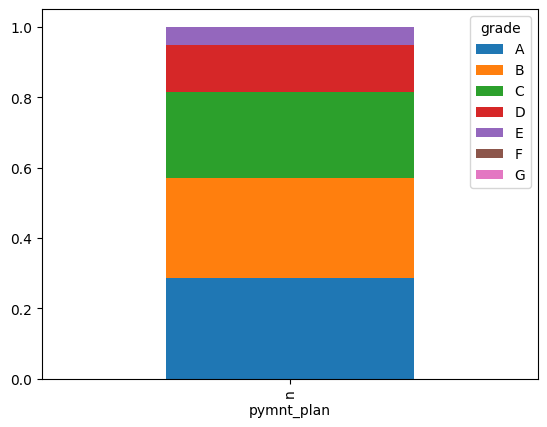

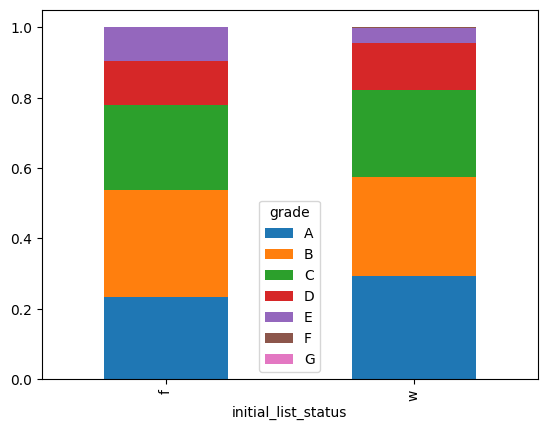

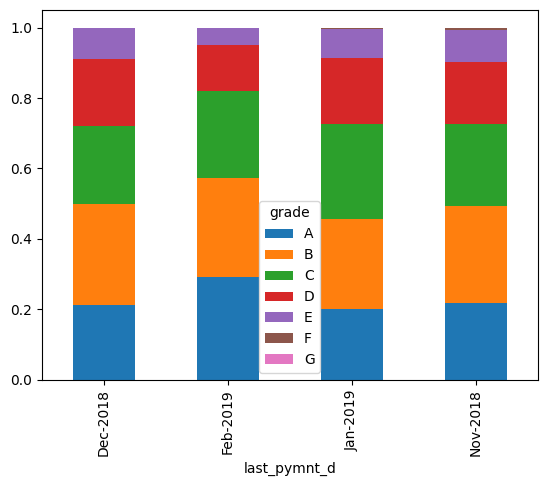

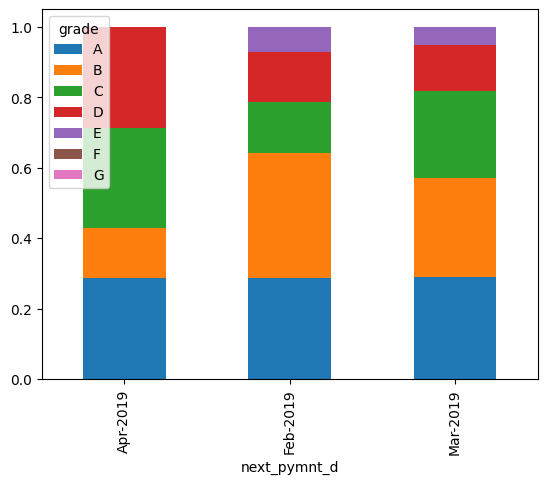

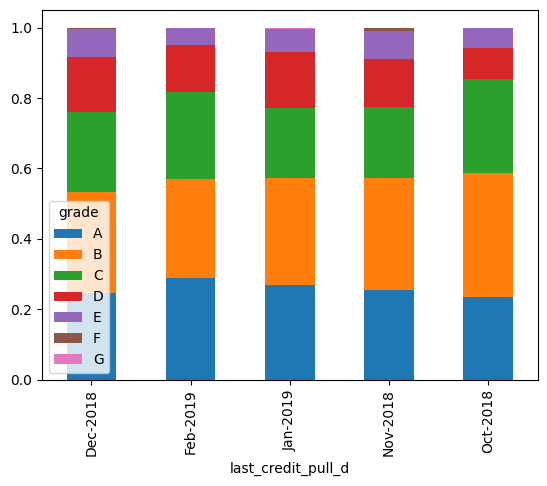

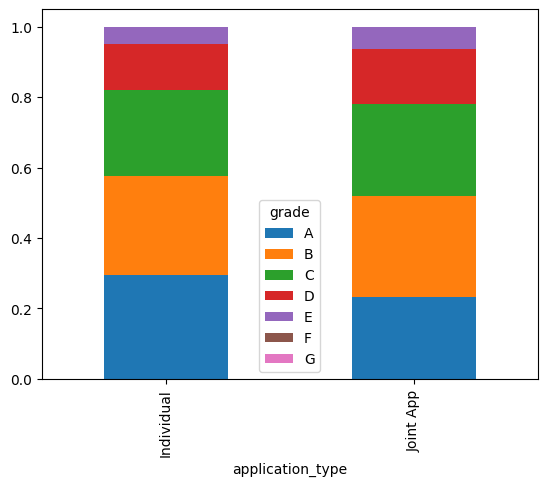

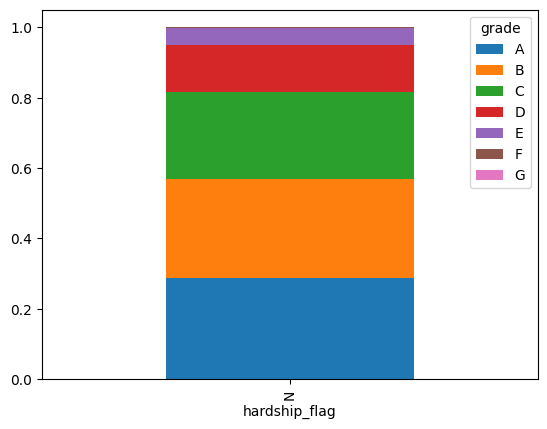

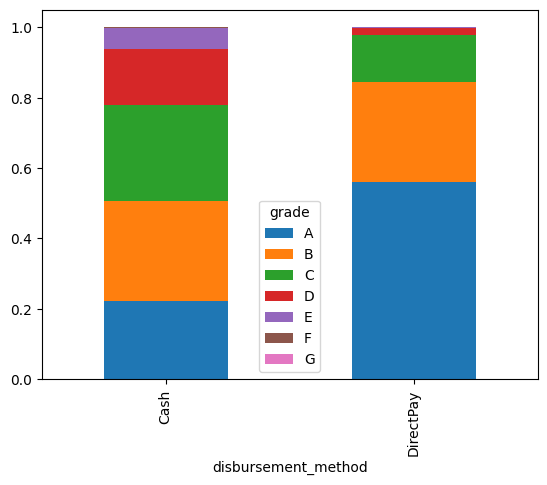

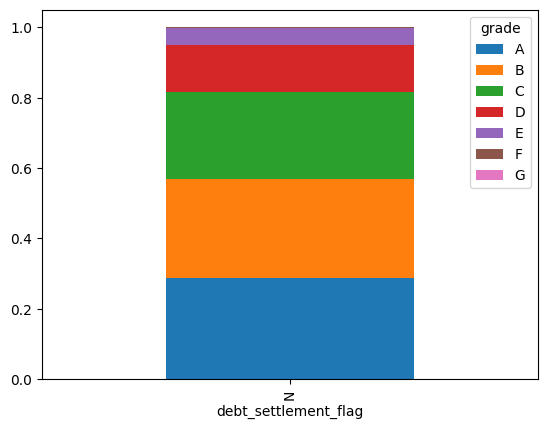

In [26]:

for var in categorical:
    if df[var].nunique() < 10: 
        pd.crosstab(df[var], df['grade'], normalize='index').plot(kind='bar', stacked=True)

### Missing value vs. target variable correlation

In [27]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_title:
grade
A    0.162803
B    0.164457
C    0.173882
D    0.162216
E    0.166444
F    0.189189
G    0.346154
Name: emp_title, dtype: float64

emp_length:
grade
A    0.081610
B    0.090463
C    0.100803
D    0.100381
E    0.100293
F    0.108108
G    0.230769
Name: emp_length, dtype: float64

mths_since_last_delinq:
grade
A    0.637346
B    0.570101
C    0.505968
D    0.480225
E    0.503868
F    0.621622
G    0.692308
Name: mths_since_last_delinq, dtype: float64

revol_util:
grade
A    0.000325
B    0.000944
C    0.001139
D    0.002510
E    0.002401
F    0.000000
G    0.038462
Name: revol_util, dtype: float64

last_pymnt_d:
grade
A    0.000417
B    0.000944
C    0.001628
D    0.001907
E    0.005868
F    0.000000
G    0.076923
Name: last_pymnt_d, dtype: float64

next_pymnt_d:
grade
A    0.019568
B    0.023170
C    0.021864
D    0.028508
E    0.034676
F    0.040541
G    0.115385
Name: next_pymnt_d, dtype: float64

mths_since_rcnt_il:
grade
A    0.030140
B    0.031853
C    0.037164
D 

### Check correlation

In [28]:
# Encode grade as numeric for correlation
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

correlations = df.select_dtypes(include='number').corr()['grade_num'].sort_values().dropna()
print(correlations.tail(10))  # most positively correlated
print(correlations.head(10))  # most negatively correlated

inq_last_12m        0.109417
inq_last_6mths      0.110477
inq_fi              0.111590
revol_util          0.253572
bc_util             0.272731
percent_bc_gt_75    0.275811
all_util            0.280111
total_rec_int       0.415063
int_rate            0.972609
grade_num           1.000000
Name: grade_num, dtype: float64
bc_open_to_buy           -0.286312
total_bc_limit           -0.237688
total_rev_hi_lim         -0.198423
pct_tl_nvr_dlq           -0.119774
tot_hi_cred_lim          -0.102203
num_bc_tl                -0.098759
mths_since_recent_inq    -0.095439
mo_sin_old_rev_tl_op     -0.093376
mort_acc                 -0.093209
mths_since_last_delinq   -0.088302
Name: grade_num, dtype: float64


In [29]:
del df['grade_num']

<Axes: xlabel='grade'>

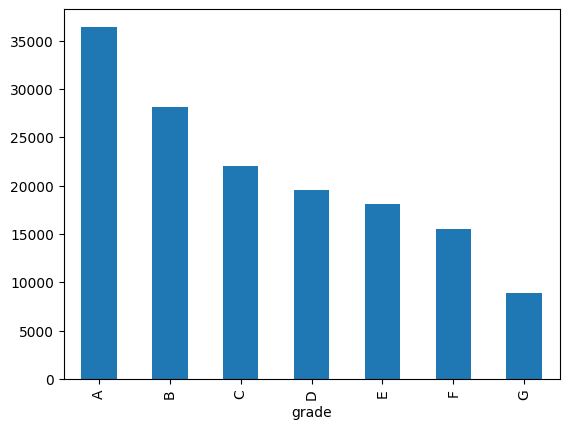

In [30]:
df.groupby('grade')['total_bc_limit'].mean().plot(kind='bar')

Text(0.5, 1.0, 'Feature Correlation Heatmap (|r| > 0.5)')

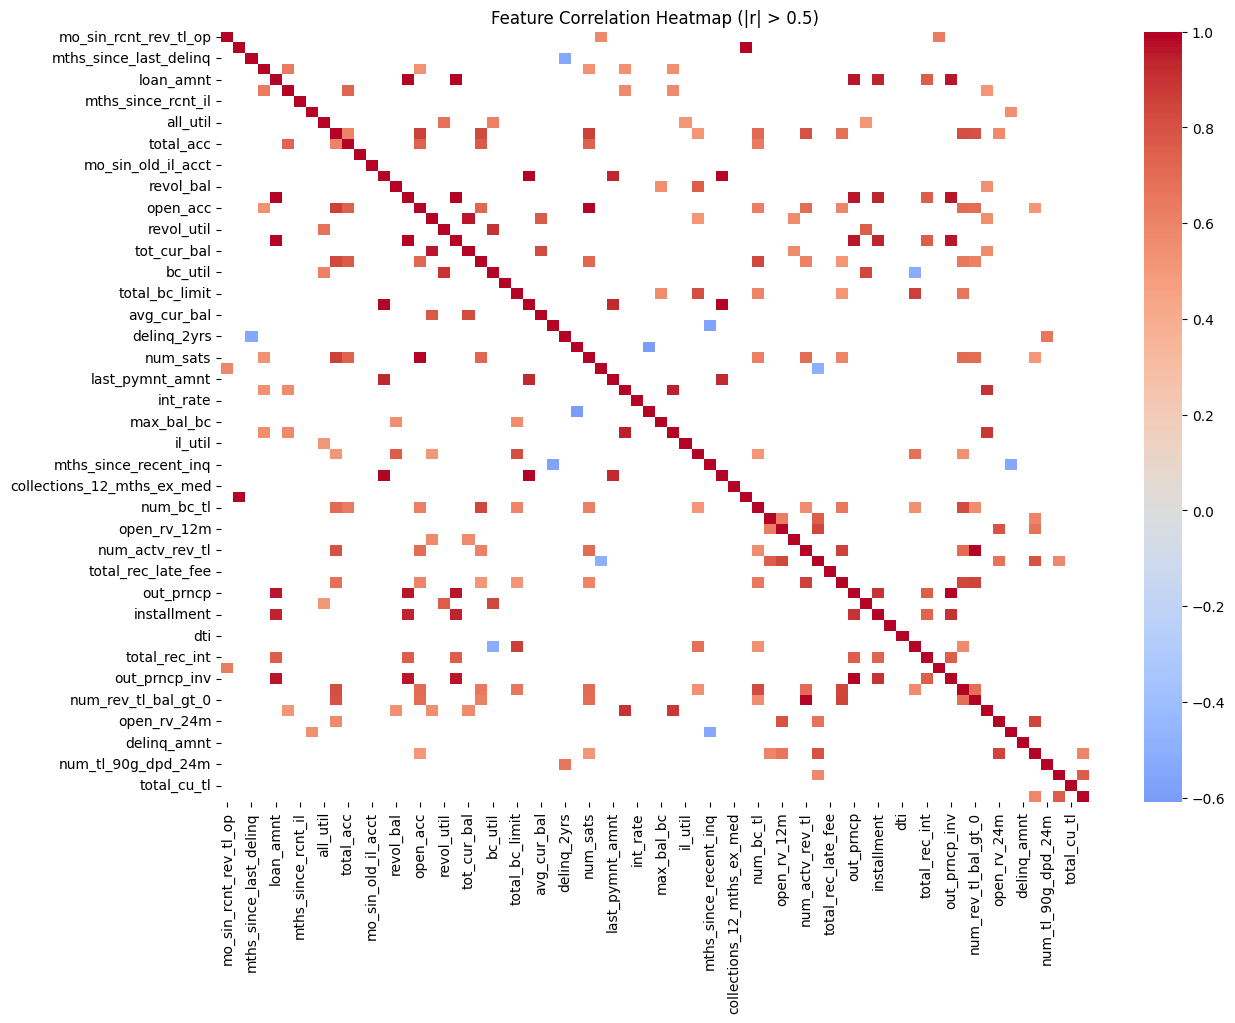

In [31]:
corr = df[list(num_features)].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            mask=corr.abs() < 0.5,  # only show meaningful correlations
            annot=False)
plt.title('Feature Correlation Heatmap (|r| > 0.5)')

### Target variable vs. missing value correlation

In [32]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_title:
grade
A    0.162803
B    0.164457
C    0.173882
D    0.162216
E    0.166444
F    0.189189
G    0.346154
Name: emp_title, dtype: float64

emp_length:
grade
A    0.081610
B    0.090463
C    0.100803
D    0.100381
E    0.100293
F    0.108108
G    0.230769
Name: emp_length, dtype: float64

mths_since_last_delinq:
grade
A    0.637346
B    0.570101
C    0.505968
D    0.480225
E    0.503868
F    0.621622
G    0.692308
Name: mths_since_last_delinq, dtype: float64

revol_util:
grade
A    0.000325
B    0.000944
C    0.001139
D    0.002510
E    0.002401
F    0.000000
G    0.038462
Name: revol_util, dtype: float64

last_pymnt_d:
grade
A    0.000417
B    0.000944
C    0.001628
D    0.001907
E    0.005868
F    0.000000
G    0.076923
Name: last_pymnt_d, dtype: float64

next_pymnt_d:
grade
A    0.019568
B    0.023170
C    0.021864
D    0.028508
E    0.034676
F    0.040541
G    0.115385
Name: next_pymnt_d, dtype: float64

mths_since_rcnt_il:
grade
A    0.030140
B    0.031853
C    0.037164
D 

### Recheck missing values

In [33]:
df.isnull().mean().sort_values(ascending = False)

,0
mths_since_last_delinq,0.558520
emp_title,0.166187
il_util,0.154427
mths_since_recent_inq,0.120893
emp_length,0.092333
mths_since_rcnt_il,0.033667
mo_sin_old_il_acct,0.033667
num_tl_120dpd_2m,0.024107
next_pymnt_d,0.023147
bc_util,0.013840


#### Drop categorical variables with more than 10 levels

This helps save the computation from encoding categorical variables

In [34]:
for var in categorical:
    if df[var].nunique() > 10:
        del df[var]

#### Drop variables with target leakage

In [35]:
try:
    del df['sub_grade']
except Exception:
    print('sub_grade was already dropped')

sub_grade was already dropped


### Data split

In [36]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

df_train.shape, df_val.shape, df_test.shape

((45000, 95), (15000, 95), (15000, 95))

In [37]:
y_train = df_train['grade']
y_val = df_val['grade']
y_test = df_test['grade']

del df_train['grade']
del df_val['grade']
del df_test['grade']


### Data preprocessing

In [38]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse = False)

train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)



### Model development

#### Baseline model

In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10, criterion='log_loss', max_features='sqrt', max_depth=5,
                               random_state=42, n_jobs=-1)


model.fit(X_train, y_train)



RandomForestClassifier(criterion='log_loss', max_depth=5, n_estimators=10,
                       n_jobs=-1, random_state=42)

In [73]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict_proba(X_val)
y_pred_class = model.predict(X_val)

print('log loss is', log_loss(y_val, y_pred))



log loss is 0.854331852520998


#### Feature importance

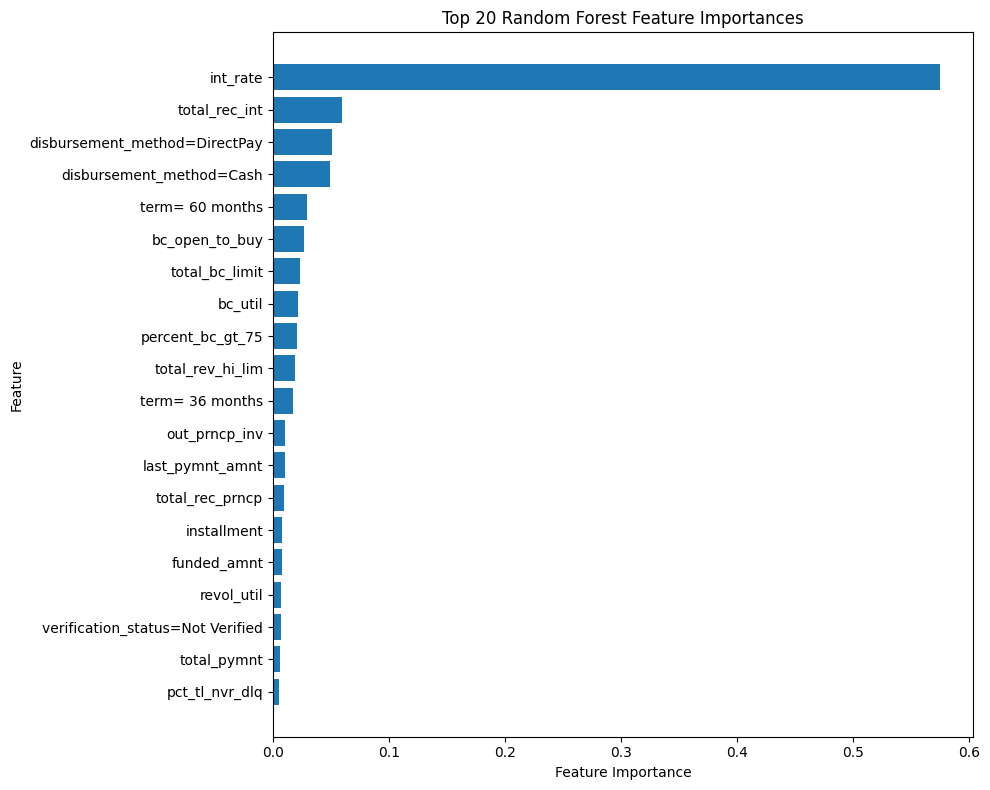

In [74]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### Hyperparameter tuning


In [75]:

scores = []

for depth in [5, 7, 9, 11, 13]:

    for min_samples in [10, 20, 30, 40]:

        model = RandomForestClassifier(n_estimators=10, 
                                       criterion='log_loss', 
                                       max_features='sqrt', 
                                       max_depth=depth,
                                       min_samples_leaf=min_samples,
                                       random_state=42, 
                                       n_jobs=-1)

        model.fit(X_train, y_train)

        from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

        y_prob = model.predict_proba(X_val)
        # for multi-class problems
        y_pred = model.classes_[y_prob.argmax(axis=1)]

        accuracy = accuracy_score(y_val, y_pred)

        logloss = log_loss(y_val, y_prob)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')


        scores.append([depth, min_samples, accuracy, logloss, macro_f1, weighted_f1])

scores_df = pd.DataFrame(scores, columns = ['max_depth', 'min_samples_leaf', 'accuracy', 'logloss', 'F1 score macro', 'F1 score weighted'])

    

In [76]:
scores_df

,max_depth,min_samples_leaf,accuracy,logloss,F1 score macro,F1 score weighted
0,5,10,0.842600,0.862084,0.502868,0.823755
1,5,20,0.846467,0.860179,0.505269,0.827631
2,5,30,0.844533,0.849035,0.504387,0.825786
3,5,40,0.844400,0.848139,0.503893,0.825564
4,7,10,0.886267,0.737561,0.532516,0.869201
5,7,20,0.858867,0.793099,0.504948,0.838717
6,7,30,0.858067,0.734651,0.499841,0.837349
7,7,40,0.918533,0.613855,0.572277,0.906314
8,9,10,0.922800,0.552604,0.582447,0.912304
9,9,20,0.915400,0.589656,0.581156,0.905588


In [77]:
def visualize_metric(metric = 'F1 score macro'):

    pivot = scores_df.pivot(
        index='max_depth',
        columns='min_samples_leaf',
        values=metric
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, aspect='auto')
    plt.colorbar(label=metric)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel('min_samples_leaf')
    plt.ylabel('max_depth')
    plt.title(f'Hyperparameter tuning heatmap: {metric}')
    plt.show()

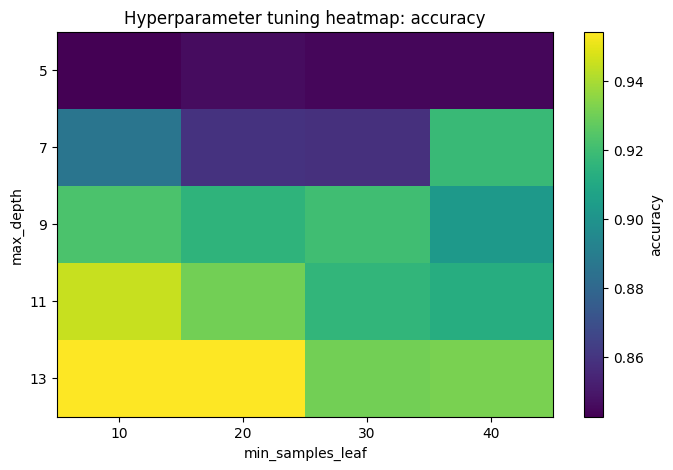

In [78]:
visualize_metric(metric = 'accuracy')

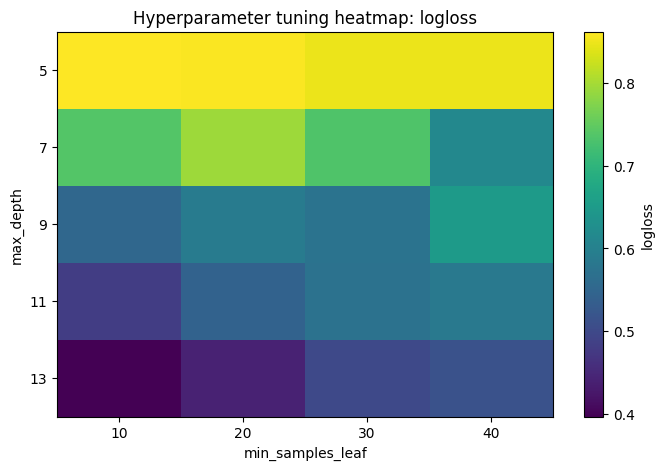

In [79]:
visualize_metric(metric = 'logloss')

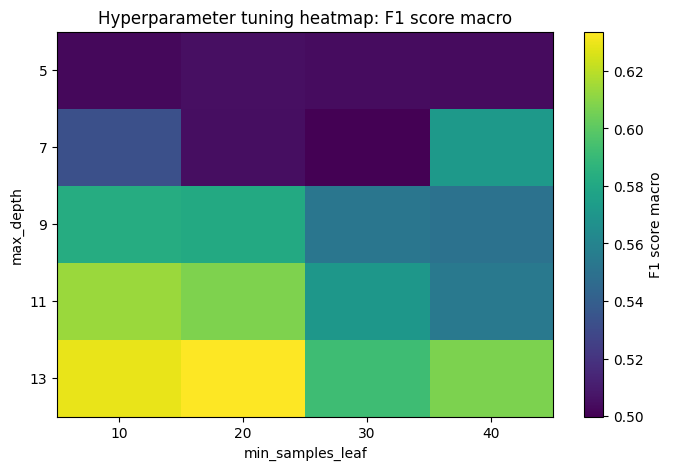

In [80]:
visualize_metric(metric = 'F1 score macro')

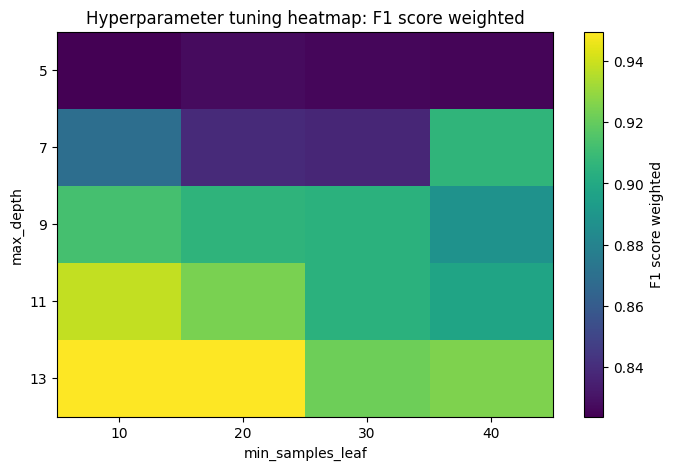

In [81]:
visualize_metric(metric = 'F1 score weighted')

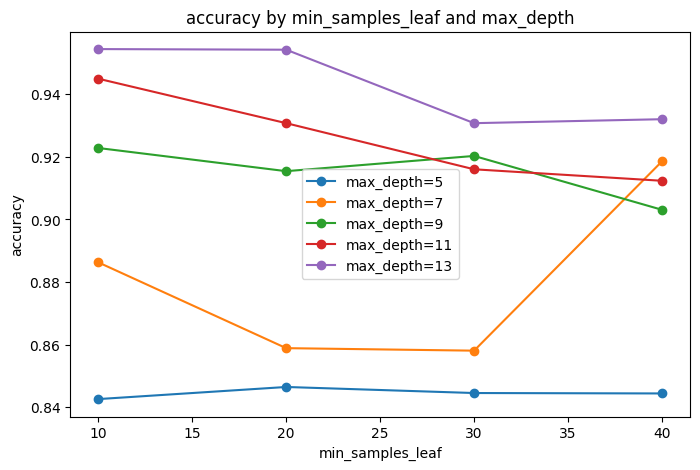

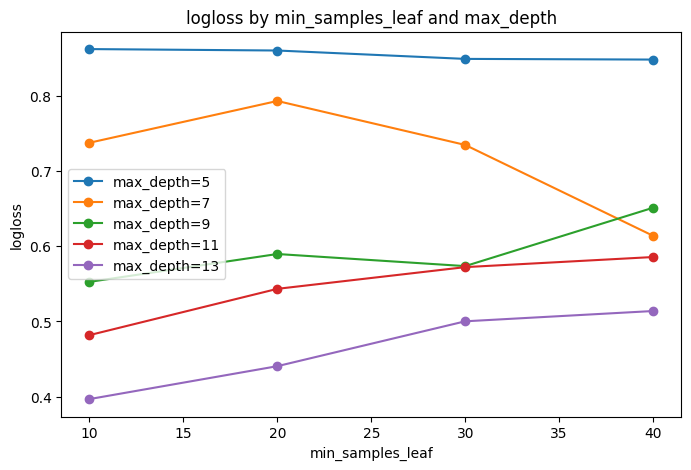

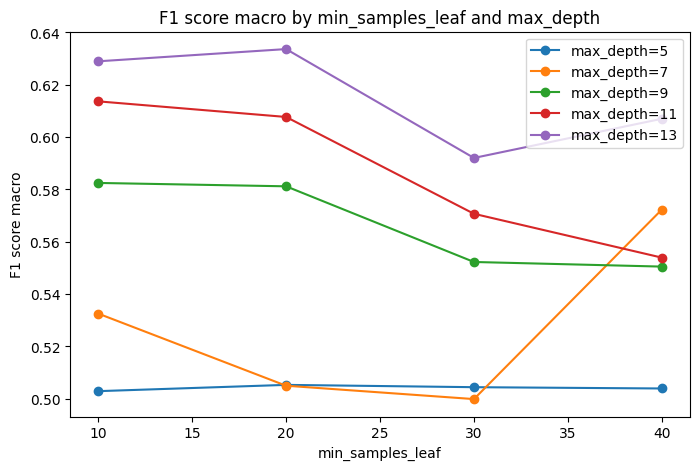

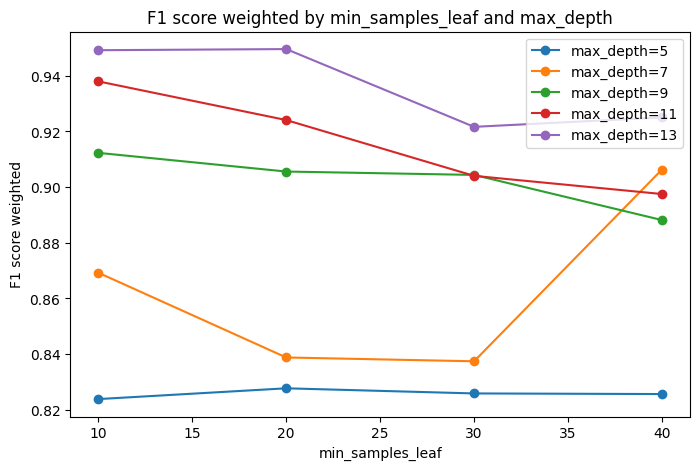

In [88]:

for metric in ['accuracy', 'logloss', 'F1 score macro', 'F1 score weighted']:

    plt.figure(figsize=(8, 5))

    for depth in sorted(scores_df['max_depth'].unique()):
        subset = scores_df[scores_df['max_depth'] == depth].sort_values('min_samples_leaf')
        plt.plot(subset['min_samples_leaf'], subset[metric], marker='o', label=f'max_depth={depth}')

    plt.xlabel('min_samples_leaf')
    plt.ylabel(metric)
    plt.title(f'{metric} by min_samples_leaf and max_depth')
    plt.legend()
    plt.show()

#### Conclusion

The best combination of hyperparameters -

- max_depth: 13
- min_samples_leaf: 20

#### Finalize random forest model

In [68]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, 
                                criterion='log_loss', 
                                max_features='sqrt', 
                                max_depth=13,
                                min_samples_leaf=20,
                                random_state=42, 
                                n_jobs=-1)

rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='log_loss', max_depth=13, min_samples_leaf=20,
                       n_estimators=10, n_jobs=-1, random_state=42)

In [69]:
import joblib

# Save
joblib.dump(rf_model, 'random_forest_model.pkl')

# Load back
rf_model = joblib.load('random_forest_model.pkl')

In [75]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

y_prob = rf_model.predict_proba(X_val)
# for multi-class problems
y_pred = rf_model.classes_[y_prob.argmax(axis=1)]

accuracy = accuracy_score(y_val, y_pred)

logloss = log_loss(y_val, y_prob)
macro_f1 = f1_score(y_val, y_pred, average='macro')
weighted_f1 = f1_score(y_val, y_pred, average='weighted')

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           A       0.97      0.97      0.97      4313
           B       0.95      0.97      0.96      4238
           C       0.91      0.98      0.94      3686
           D       0.80      0.84      0.82      1993
           E       0.83      0.29      0.44       750
           F       0.00      0.00      0.00        15
           G       0.00      0.00      0.00         5

    accuracy                           0.92     15000
   macro avg       0.64      0.58      0.59     15000
weighted avg       0.92      0.92      0.91     15000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Feature importance

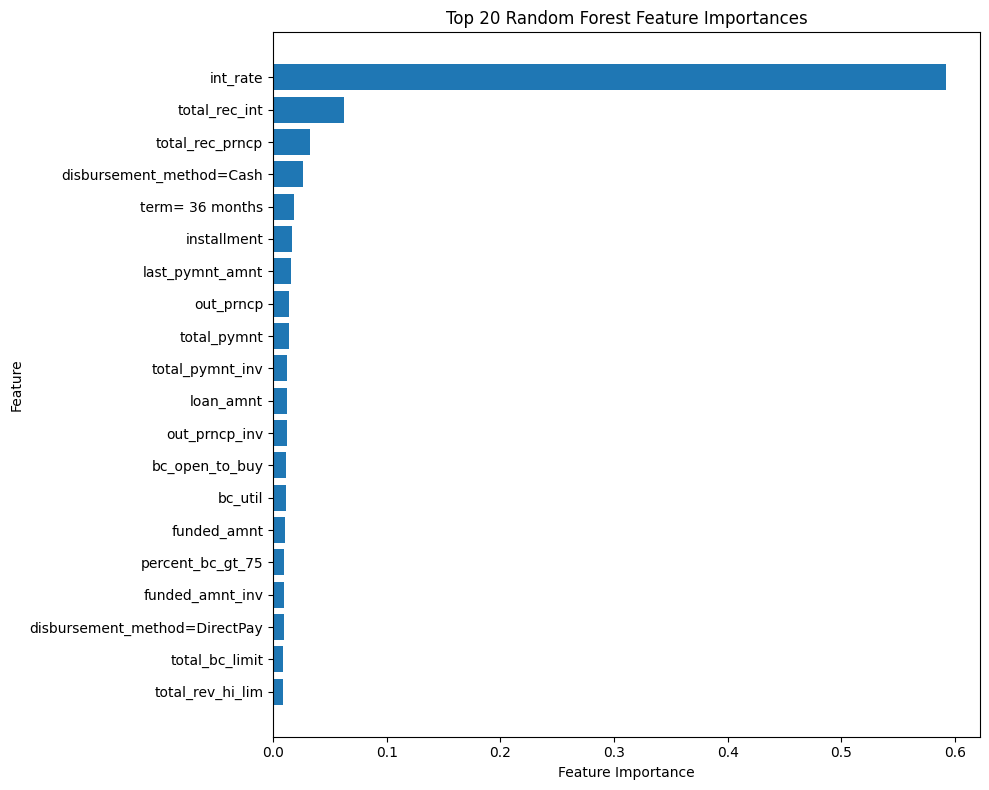

In [83]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### Neural Networks

1. Prepare the Data for PyTorch

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # should print: Using device: cuda

Using device: cuda


In [53]:
# missing values treatment
# this is a must
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

In [54]:

# Encode target to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 'A'->0, 'B'->1, etc.
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Convert to tensors — X_train is already our DictVectorizer output
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.LongTensor(y_train_enc)
y_val_tensor = torch.LongTensor(y_val_enc)
y_test_tensor = torch.LongTensor(y_test_enc)

In [55]:
# create dataset class

class LoanDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [56]:
# create dataloaders

train_loader = DataLoader(
    LoanDataset(X_train_tensor, y_train_tensor),
    batch_size=512,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)
val_loader = DataLoader(
    LoanDataset(X_val_tensor, y_val_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)
test_loader = DataLoader(
    LoanDataset(X_test_tensor, y_test_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

In [57]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [58]:
input_dim = X_train.shape[1]
model = LoanGradeMLP(input_dim=input_dim, num_classes=7).to(device)

In [59]:

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
class_counts  = np.bincount(y_train_enc)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [60]:
# ── Train / eval functions ────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [61]:
# ── Training loop ─────────────────────────────────────────────────────────────
num_epochs    = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_nn_model.pth')
        print("  -> Best model saved")

Epoch 01 | Train Loss: 1.9338  Acc: 0.2058 | Val Loss: 1.8553  Acc: 0.2390
  -> Best model saved
Epoch 02 | Train Loss: 1.8541  Acc: 0.2506 | Val Loss: 1.7793  Acc: 0.2446
  -> Best model saved
Epoch 03 | Train Loss: 1.8148  Acc: 0.2455 | Val Loss: 1.7551  Acc: 0.2546
  -> Best model saved
Epoch 04 | Train Loss: 1.8118  Acc: 0.2470 | Val Loss: 1.7435  Acc: 0.2567
  -> Best model saved
Epoch 05 | Train Loss: 1.7650  Acc: 0.2544 | Val Loss: 1.7267  Acc: 0.2853
  -> Best model saved
Epoch 06 | Train Loss: 1.7771  Acc: 0.2578 | Val Loss: 1.7322  Acc: 0.3003
Epoch 07 | Train Loss: 1.7462  Acc: 0.2519 | Val Loss: 1.7301  Acc: 0.2273
Epoch 08 | Train Loss: 1.7298  Acc: 0.2592 | Val Loss: 1.7194  Acc: 0.2801
  -> Best model saved
Epoch 09 | Train Loss: 1.7354  Acc: 0.2608 | Val Loss: 1.7158  Acc: 0.2703
  -> Best model saved
Epoch 10 | Train Loss: 1.7272  Acc: 0.2556 | Val Loss: 1.6889  Acc: 0.3021
  -> Best model saved
Epoch 11 | Train Loss: 1.7134  Acc: 0.2747 | Val Loss: 1.7164  Acc: 0.2390

In [64]:
# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score

model.load_state_dict(torch.load('best_nn_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)

y_pred_labels = le.inverse_transform(all_preds)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, y_pred_labels, target_names=list('ABCDEFG')))
print(f"Weighted F1: {f1_score(y_test_labels, y_pred_labels, average='weighted'):.4f}")
print(f"Macro F1:    {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")

              precision    recall  f1-score   support

           A       0.46      0.64      0.54      4313
           B       0.34      0.15      0.21      4238
           C       0.32      0.18      0.23      3687
           D       0.23      0.27      0.25      1992
           E       0.10      0.24      0.14       750
           F       0.01      0.40      0.02        15
           G       0.01      0.40      0.01         5

    accuracy                           0.32     15000
   macro avg       0.21      0.33      0.20     15000
weighted avg       0.34      0.32      0.31     15000

Weighted F1: 0.3110
Macro F1:    0.2001


#### Increase model complexity

In [ ]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)